In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import pickle 
import json
from pathlib import Path

# ==============================================================================
# 1. DATA LOADING & PREPARATION
# ==============================================================================
DATA_DIR = Path("../data")

# A. Load Dam Data
try:
    dam = pd.read_csv(DATA_DIR / "dam_data.csv", header=0)
    
    # Standardize column names
    first_col = dam.columns[0]
    dam = dam.rename(columns={first_col: "timestamp"})
    dam["timestamp"] = pd.to_datetime(dam["timestamp"], dayfirst=True)

    # Select and rename key columns
    level_col = "Cota da albufeira na última hora (m)"
    volume_col = "Volume armazenado na última hora (dam3)"
    
    dam_simple = dam[["timestamp", level_col, volume_col]].copy()
    dam_simple = dam_simple.rename(columns={
        level_col: "water_level_m",
        volume_col: "water_volume_dam3",
    })
    dam_simple = dam_simple.dropna(subset=["water_volume_dam3"])

    # Aggregate to Daily (Mean)
    dam_daily = (
        dam_simple
        .set_index("timestamp")
        .resample("D")
        .mean(numeric_only=True)
        .reset_index()
        .rename(columns={"timestamp": "date"})
    )
    
    # Calculate Percentage
    dam_daily["water_volume_pct"] = (
        dam_daily["water_volume_dam3"] / dam_daily["water_volume_dam3"].max() * 100
    )
    
    print("✅ Dam data loaded.")

except Exception as e:
    print(f"❌ Error loading dam data: {e}")

# B. Load Weather Data (JSON)
try:
    with open(DATA_DIR / "openweather_day_summary.json", "r", encoding="utf-8") as f:
        weather_raw = json.load(f)

    # Parse JSON to DataFrame
    records = []
    for date_str, payload in weather_raw.items():
        rec = {
            "date": pd.to_datetime(date_str),
            "precip_total_mm": payload["precipitation"]["total"],
            "temp_max_K": payload["temperature"]["max"],
            "temp_min_K": payload["temperature"]["min"],
            "temp_afternoon_K": payload["temperature"]["afternoon"],
            "humidity_afternoon": payload["humidity"]["afternoon"],
            "clouds_afternoon": payload["cloud_cover"]["afternoon"],
            "pressure_afternoon": payload["pressure"]["afternoon"],
            "wind_max_speed": payload["wind"]["max"]["speed"],
            "wind_max_dir": payload["wind"]["max"]["direction"],
            "tz": payload.get("tz"),
        }
        records.append(rec)

    df_weather = pd.DataFrame(records)
    df_weather = df_weather.sort_values("date").reset_index(drop=True)
    
    # Convert Kelvin to Celsius
    for col in ["temp_max_K", "temp_min_K", "temp_afternoon_K"]:
        df_weather[col.replace("_K", "_C")] = df_weather[col] - 273.15

    print("✅ Weather JSON loaded (with Pressure, Wind Dir, TZ).")

except Exception as e:
    print(f"❌ Error loading weather data: {e}")

# C. Merge Datasets
dam_daily = dam_daily.sort_values("date")
df_weather = df_weather.sort_values("date")

# Time-aware merge
df = pd.merge_asof(
    dam_daily,
    df_weather,
    on="date",
    direction="nearest",
    tolerance=pd.Timedelta("1 day")
)

# Clean final dataset (Remove missing dam days)
df = df.dropna(subset=["water_volume_pct"]).reset_index(drop=True)

print(f"✅ Merged Dataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# ==============================================================================
# 2. PHYSICS-INFORMED FEATURE ENGINEERING & TARGET PREPARATION
# ==============================================================================
print("Generating physics-based features...")

# --- A. Setup Configuration ---
FORECAST_HORIZON_DAYS = 7
LAG_DAYS = [1, 2, 3, 7, 14]

# Features to "simulate" future weather for
FORECAST_FEATURES = [
    "precip_total_mm", "temp_max_C", "temp_min_C", 
    "temp_afternoon_C", "humidity_afternoon", "clouds_afternoon", "wind_max_speed"
]

# Noise injection to simulate imperfect weather forecasts (prevents overfitting)
FORECAST_NOISE = {
    "precip_total_mm": {"rel": 0.15, "abs": 0.5, "lower": 0},
    "wind_max_speed":  {"rel": 0.10, "abs": 0.10, "lower": 0},
}

rng = np.random.default_rng(42)

def noisy_forecast(series, rel_noise=0.05, abs_noise=0.2, lower=None):
    """Add controlled noise to future weather to avoid overfitting to perfect hindsight."""
    std = abs_noise + rel_noise * series.abs()
    noise = pd.Series(rng.normal(0.0, 1.0, size=len(series)), index=series.index) * std
    noisy = series + noise
    if lower is not None:
        noisy = noisy.clip(lower=lower)
    return noisy

# --- B. Physics Features (Inertia & Saturation) ---
# 1. Volume Dynamics (Velocity/Trend)
df["vol_change_1d"] = df["water_volume_pct"].diff(1)
df["vol_change_3d_mean"] = df["vol_change_1d"].rolling(window=3).mean()

# 2. Lagged History
for lag in LAG_DAYS:
    df[f"water_volume_pct_lag_{lag}"] = df["water_volume_pct"].shift(lag)

# 3. Soil Saturation Proxies (Cumulative Rain)
# Added 15d and 30d to capture long-term saturation
df["precip_3d_sum"] = df["precip_total_mm"].rolling(window=3).sum()
df["precip_7d_sum"] = df["precip_total_mm"].rolling(window=7).sum()
df["precip_15d_sum"] = df["precip_total_mm"].rolling(window=15).sum()
df["precip_30d_sum"] = df["precip_total_mm"].rolling(window=30).sum()

# 4. Seasonal Indicators
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

# --- C. Target Creation & Future Weather ---
target_cols_abs = []
target_cols_delta = []
forecast_feature_cols = []

for h in range(1, FORECAST_HORIZON_DAYS + 1):
    # 1. Absolute Target
    col_abs = f"target_volume_d{h}"
    df[col_abs] = df["water_volume_pct"].shift(-h)
    target_cols_abs.append(col_abs)
    
    # 2. Delta Target (The Physics Target)
    col_delta = f"target_delta_d{h}"
    df[col_delta] = df[col_abs] - df["water_volume_pct"]
    target_cols_delta.append(col_delta)

    # 3. Future Weather Features (Simulated Forecasts)
    for feat in FORECAST_FEATURES:
        base_forecast = df[feat].shift(-h)
        noise_cfg = FORECAST_NOISE.get(feat, {"rel": 0.03, "abs": 0.2, "lower": None})
        
        col_name = f"{feat}_forecast_d{h}"
        df[col_name] = noisy_forecast(
            base_forecast,
            rel_noise=noise_cfg.get("rel", 0.03),
            abs_noise=noise_cfg.get("abs", 0.2),
            lower=noise_cfg.get("lower"),
        )
        forecast_feature_cols.append(col_name)

# --- D. Final Cleanup ---
# We must drop NaNs created by rolling windows (30 days) and future shifts (7 days)
df_model = df.dropna().reset_index(drop=True)

print(f"Feature Engineering Complete.")
print(f"Final Dataset Shape: {df_model.shape}") 

✅ Dam data loaded.
✅ Weather JSON loaded (with Pressure, Wind Dir, TZ).
✅ Merged Dataset Shape: (991, 17)
Date Range: 2023-01-01 00:00:00 to 2025-10-24 00:00:00
Generating physics-based features...
Feature Engineering Complete.
Final Dataset Shape: (955, 93)


In [11]:
# ==============================================================================
# 4. TRAIN/TEST SPLIT
# ==============================================================================
# Select only relevant features (exclude targets and raw dates)
feature_cols = [
    c for c in df_model.columns 
    if "lag" in c or "precip" in c or "change" in c or "month" in c or "dayofyear" in c 
    or "temp" in c or "humidity" in c or "wind" in c
]

X = df_model[feature_cols]
Y_delta = df_model[target_cols_delta]

# Time-aware split (80% Train, 20% Test)
split_idx = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y_delta.iloc[:split_idx], Y_delta.iloc[split_idx:]

# Keep absolute values for final validation
Y_test_abs = df_model.iloc[split_idx:][target_cols_abs]
current_vol_test = df_model.iloc[split_idx:]["water_volume_pct"].values.reshape(-1, 1)

# ==============================================================================
# 5. HYPERPARAMETER TUNING (RANDOMIZED SEARCH)
# ==============================================================================
print("=== Starting Hyperparameter Optimization (Target: Day +1) ===")
print("Note: Optimizing on Day 1 delta provides a robust baseline for all horizons.")

# Define the search space
param_grid = {
    'n_estimators': [200, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Base model
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

tscv = TimeSeriesSplit(n_splits=3)

# Randomized Search (Faster than Grid Search)
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,                      # Try 15 random combinations
    scoring='neg_mean_absolute_error',
    cv=tscv,                           # 3-Fold Cross-Validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit on Day 1 Delta
search.fit(X_train, Y_train['target_delta_d1'])

best_params = search.best_params_
print(f"\n✅ Optimization Complete.")
print(f"Best Parameters Found: {best_params}")

=== Starting Hyperparameter Optimization (Target: Day +1) ===
Note: Optimizing on Day 1 delta provides a robust baseline for all horizons.
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Optimization Complete.
Best Parameters Found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [12]:
# ==============================================================================
# 6. FINAL MODEL TRAINING (OPTIMIZED)
# ==============================================================================
print(f"Training final Multi-Horizon model with optimized params...")

# 1. Instantiate model with the best parameters found in Tuning
xgb_final = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

# 2. Wrap in MultiOutputRegressor (to predict 7 days at once)
model = MultiOutputRegressor(xgb_final)

# 3. Fit the model on the training set
model.fit(X_train, Y_train)

print("Training Complete.")

# ==============================================================================
# 7. EVALUATION & RECONSTRUCTION
# ==============================================================================
# 1. Predict Deltas (Volume Variations)
y_pred_delta = model.predict(X_test)

# 2. Reconstruct Absolute Values: Forecast = Current + Predicted_Delta
# Note: numpy broadcasting adds the current volume to each of the 7 predicted deltas
y_pred_abs_values = current_vol_test + y_pred_delta

# 3. Convert to DataFrame for easier analysis
y_pred_abs = pd.DataFrame(
    y_pred_abs_values, 
    columns=target_cols_abs, 
    index=Y_test.index
)

print("Predictions reconstructed successfully.")

# ==============================================================================
# 8. EXPORT FOR PRODUCTION (NODE-RED)
# ==============================================================================
export_data = {
    "model": model,
    "features": feature_cols,
    "best_params": best_params
}

filename = 'dam_forecast_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(export_data, f)

print(f"\n✅ Model saved to '{filename}'. Ready for integration.")

Training final Multi-Horizon model with optimized params...
Training Complete.
Predictions reconstructed successfully.

✅ Model saved to 'dam_forecast_model.pkl'. Ready for integration.


In [13]:
# ==============================================================================
# 9. BENCHMARKING (XGBoost vs Baseline)
# ==============================================================================
print("Calculating Baseline performance for comparison...")

# 1. Baseline: "Tomorrow is equal to Today" (Persistence)
# We repeat the current known volume for all 7 days
baseline_pred = np.repeat(current_vol_test, FORECAST_HORIZON_DAYS, axis=1)

# 2. Calculate Errors (MAE)
baseline_mae = []
xgb_mae = []

for i, col in enumerate(target_cols_abs):
    # Baseline Error
    b_error = mean_absolute_error(Y_test_abs[col], baseline_pred[:, i])
    baseline_mae.append(b_error)
    
    # XGBoost Error (from previous cell)
    x_error = mean_absolute_error(Y_test_abs[col], y_pred_abs.iloc[:, i])
    xgb_mae.append(x_error)

# 3. Create Comparison DataFrame
df_results = pd.DataFrame({
    "Horizon (Day)": range(1, FORECAST_HORIZON_DAYS + 1),
    "Baseline MAE": baseline_mae,
    "XGBoost MAE": xgb_mae
})

df_results["Improvement"] = df_results["Baseline MAE"] - df_results["XGBoost MAE"]
df_results["Improvement (%)"] = (df_results["Improvement"] / df_results["Baseline MAE"]) * 100

print("\n--- PERFORMANCE SUMMARY ---")
print(df_results.round(4))
print(f"\nAverage Improvement: {df_results['Improvement'].mean():.4f} percentage points")

Calculating Baseline performance for comparison...

--- PERFORMANCE SUMMARY ---
   Horizon (Day)  Baseline MAE  XGBoost MAE  Improvement  Improvement (%)
0              1        1.5962       1.5732       0.0229           1.4370
1              2        2.2631       2.2113       0.0518           2.2903
2              3        2.7253       2.6409       0.0844           3.0954
3              4        2.9184       2.8154       0.1030           3.5295
4              5        2.8770       2.7672       0.1098           3.8167
5              6        2.6896       2.5287       0.1608           5.9804
6              7        2.7999       2.6042       0.1958           6.9917

Average Improvement: 0.1041 percentage points


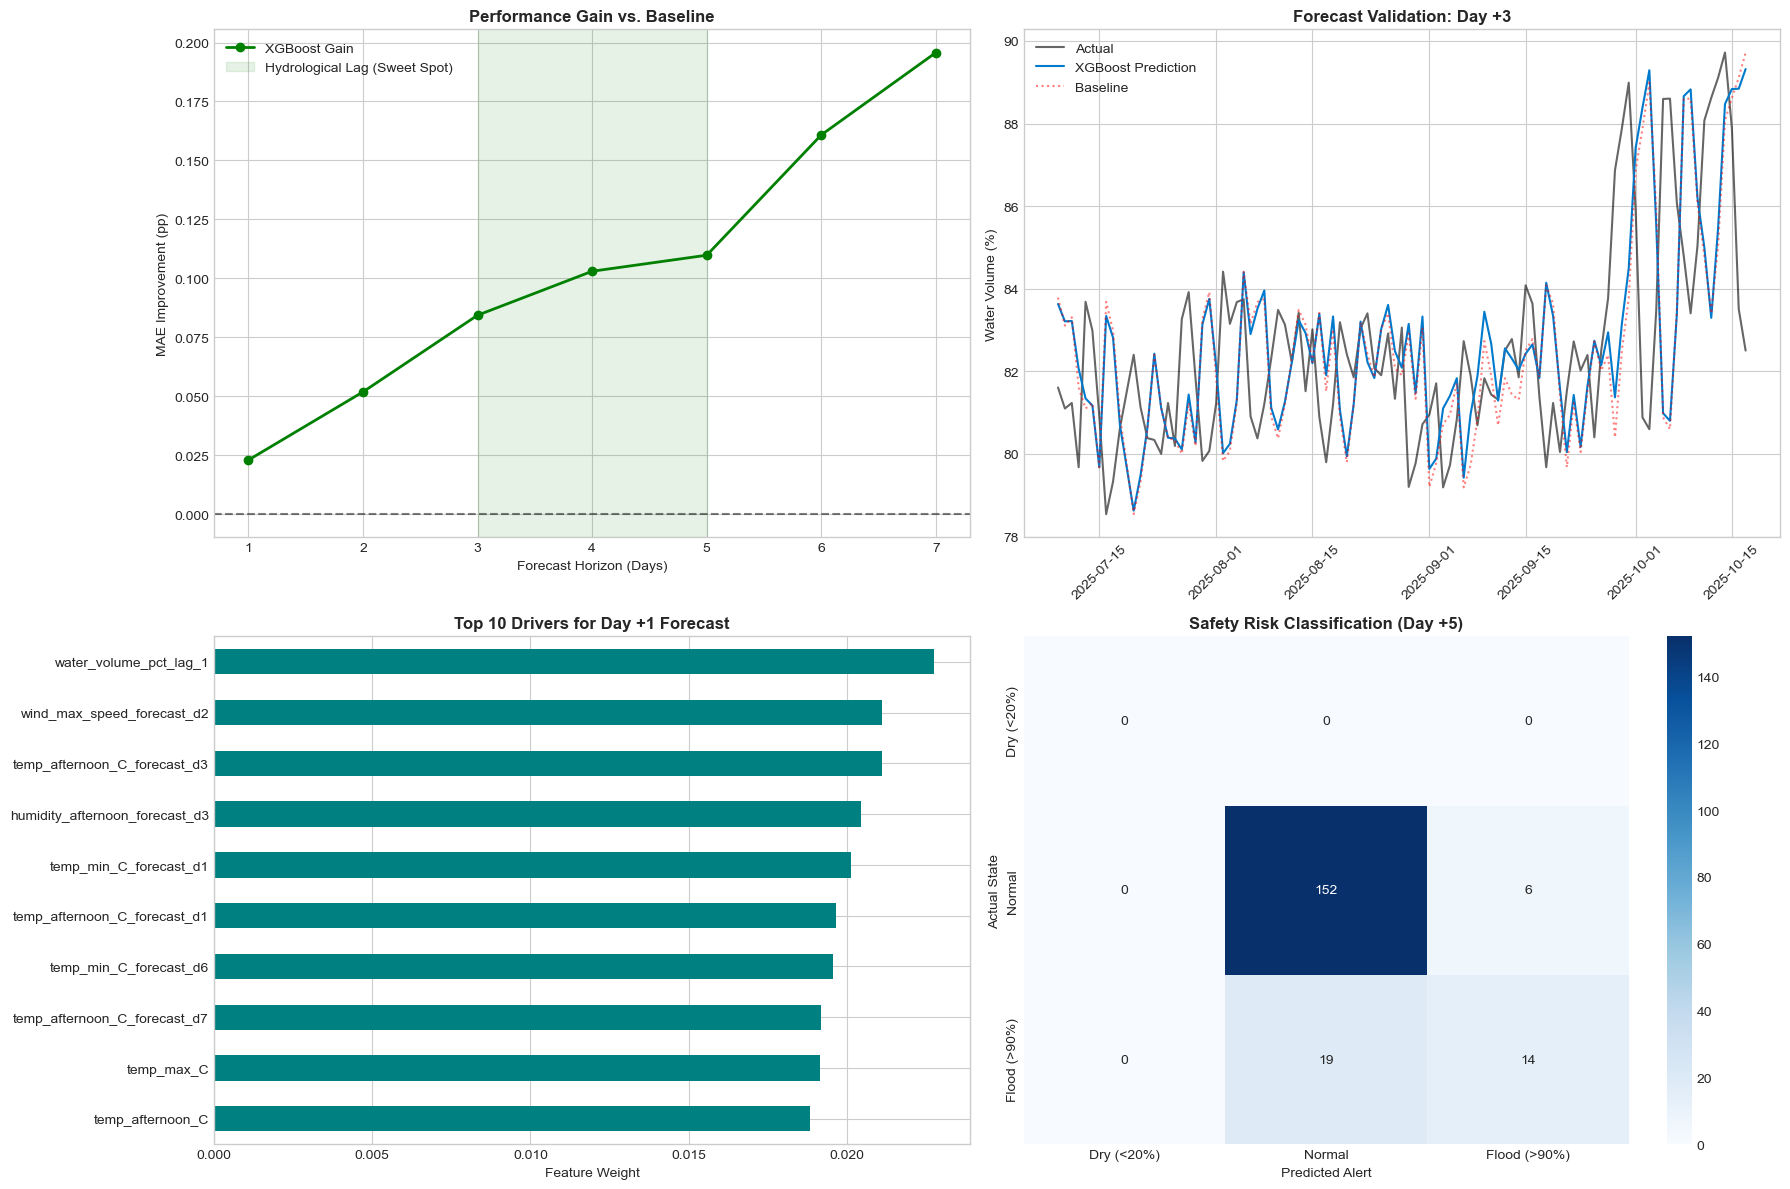

In [14]:
# ==============================================================================
# 10. VISUALIZATION DASHBOARD
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# --- PLOT A: WHERE DOES AI BEAT THE BASELINE? ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_results["Horizon (Day)"], df_results["Improvement"], 
         marker='o', color='green', linewidth=2, label='XGBoost Gain')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
# Highlight the "Sweet Spot" (Runoff delay)
if len(df_results) >= 5:
    ax1.axvspan(3, 5, color='green', alpha=0.1, label='Hydrological Lag (Sweet Spot)')
ax1.set_title("Performance Gain vs. Baseline", fontsize=12, fontweight='bold')
ax1.set_xlabel("Forecast Horizon (Days)")
ax1.set_ylabel("MAE Improvement (pp)")
ax1.legend()

# --- PLOT B: FORECAST VS ACTUAL (Day +3 Example) ---
# We show Day 3 because it's usually where the model shines
ax2 = fig.add_subplot(gs[0, 1])
day_idx = 2 # Day 3 (index 2)
col_name = target_cols_abs[day_idx]
# Plot last 100 days for clarity
subset_idx = -100 
dates = df_model["date"].iloc[split_idx:].iloc[subset_idx:]

ax2.plot(dates, Y_test_abs[col_name].iloc[subset_idx:], label="Actual", color='black', alpha=0.6)
ax2.plot(dates, y_pred_abs[col_name].iloc[subset_idx:], label="XGBoost Prediction", color='#007acc', linewidth=1.5)
ax2.plot(dates, baseline_pred[subset_idx:, day_idx], label="Baseline", color='red', linestyle=':', alpha=0.5)
ax2.set_title(f"Forecast Validation: Day +{day_idx+1}", fontsize=12, fontweight='bold')
ax2.set_ylabel("Water Volume (%)")
ax2.legend()
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# --- PLOT C: FEATURE IMPORTANCE (Day 1) ---
ax3 = fig.add_subplot(gs[1, 0])
# Get importance from the first estimator (Day 1)
fi = pd.Series(model.estimators_[0].feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
fi.plot(kind='barh', color='teal', ax=ax3)
ax3.set_title("Top 10 Drivers for Day +1 Forecast", fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.set_xlabel("Feature Weight")

# --- PLOT D: SAFETY RISK MATRIX ---
ax4 = fig.add_subplot(gs[1, 1])
RISK_HORIZON = 5 # Evaluate risk at Day 5 (Critical planning horizon)

def classify_risk(vol):
    if vol < 20: return "Dry (<20%)"
    if vol > 90: return "Flood (>90%)"
    return "Normal"

risk_true = Y_test_abs[f"target_volume_d{RISK_HORIZON}"].apply(classify_risk)
risk_pred = y_pred_abs[f"target_volume_d{RISK_HORIZON}"].apply(classify_risk)
labels = ["Dry (<20%)", "Normal", "Flood (>90%)"]

cm = confusion_matrix(risk_true, risk_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax4)
ax4.set_title(f"Safety Risk Classification (Day +{RISK_HORIZON})", fontsize=12, fontweight='bold')
ax4.set_xlabel("Predicted Alert")
ax4.set_ylabel("Actual State")

plt.tight_layout()
plt.show()